In [33]:
import warnings
warnings.filterwarnings('ignore')

In [8]:
ls


 sample_data/           'Sentiment_Data 4.csv'
'Sentiment_Data 3.csv'   Sentiment_Data.csv


In [9]:
import pandas as pd

data = pd.read_csv("Sentiment_Data.csv", encoding='ISO-8859-1')
print(data.info())
print(data['Sentiment'].value_counts())
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43456 entries, 0 to 43455
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tweet      43456 non-null  object
 1   Sentiment  43456 non-null  object
dtypes: object(2)
memory usage: 679.1+ KB
None
Sentiment
Strong_Pos    22737
Neutral        6669
Mild_Pos       6291
Strong_Neg     4281
Mild_Neg       3478
Name: count, dtype: int64


,Tweet,Sentiment
0,@_angelica_toy Happy Anniversary!!!....The Day...,Mild_Pos
1,@McfarlaneGlenda Happy Anniversary!!!....The D...,Mild_Pos
2,@thevivafrei @JustinTrudeau Happy Anniversary!...,Mild_Pos
3,@NChartierET Happy Anniversary!!!....The Day t...,Mild_Pos
4,@tabithapeters05 Happy Anniversary!!!....The D...,Mild_Pos


In [10]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 16.4 MB/s eta 0:00:00


In [11]:
import pandas as pd
import re
import emoji
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(data, test_size=0.3, stratify=data['Sentiment'], random_state=42)

print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")
print("Train label distribution:\n", train_df['Sentiment'].value_counts(normalize=True))
print("Test label distribution:\n", test_df['Sentiment'].value_counts(normalize=True))


Train size: 30419, Test size: 13037
Train label distribution:
 Sentiment
Strong_Pos    0.523226
Neutral       0.153457
Mild_Pos      0.144778
Strong_Neg    0.098524
Mild_Neg      0.080016
Name: proportion, dtype: float64
Test label distribution:
 Sentiment
Strong_Pos    0.523203
Neutral       0.153486
Mild_Pos      0.144742
Strong_Neg    0.098489
Mild_Neg      0.080080
Name: proportion, dtype: float64


In [12]:
# Regex Cleaning
def regex_clean(text):
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)       # Remove URLs
    text = re.sub(r'@\w+', '', text)                        # Remove mentions
    text = re.sub(r'#\w+', '', text)                        # Remove hashtags
    text = re.sub(r'[^\w\s]', '', text)                     # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()                # Remove extra spaces
    return text

# Emoji Handling
def handle_emojis(text):
    return emoji.demojize(text, delimiters=(" ", " "))

# Slang Replacement
slang_dict = {
    "idk": "i do not know", "lol": "laugh out loud", "omg": "oh my god",
    "brb": "be right back", "btw": "by the way", "ttyl": "talk to you later",
    "imo": "in my opinion", "fyi": "for your information", "smh": "shaking my head",
    "tbh": "to be honest", "lmao": "laughing my ass off", "rofl": "rolling on the floor laughing",
    "np": "no problem", "yw": "you are welcome", "bff": "best friends forever",
    "afaik": "as far as i know", "ikr": "i know right", "jk": "just kidding",
    "nvm": "never mind", "omw": "on my way", "thx": "thanks", "ty": "thank you",
    "gr8": "great", "plz": "please", "wtf": "what the fuck", "wth": "what the hell",
    "fomo": "fear of missing out", "irl": "in real life", "tmi": "too much information",
    "cya": "see you", "cu": "see you", "dm": "direct message", "ftw": "for the win",
    "ftl": "for the loss", "gg": "good game", "gl": "good luck", "wyd": "what are you doing",
    "yolo": "you only live once"
}

def replace_slangs(text):
    words = text.split()
    return " ".join([slang_dict.get(w, w) for w in words])

# Negation Handling
def negation_handling(text):
    negation_words = {'not', 'no', 'never', "n't"}
    tokens = text.split()
    new_tokens = []
    negate = False
    count = 0
    for token in tokens:
        if token in negation_words:
            negate = True
            count = 0
            new_tokens.append(token)
        elif negate:
            new_tokens.append("not_" + token)
            count += 1
            if count >= 5:
                negate = False
        else:
            new_tokens.append(token)
    return " ".join(new_tokens)

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = regex_clean(text)
    text = handle_emojis(text)
    text = replace_slangs(text)
    text = negation_handling(text)
    return text

# Label Mapping Function
def map_sentiment(label):
    mapping = {
        'Strong_Pos': 'Positive',
        'Mild_Pos': 'Positive',
        'Neutral': 'Neutral',
        'Mild_Neg': 'Negative',
        'Strong_Neg': 'Negative'
    }
    return mapping.get(label, label)

In [13]:
train_df['cleaned'] = train_df['Tweet'].fillna('').astype(str).apply(preprocess_text)
test_df['cleaned'] = test_df['Tweet'].fillna('').astype(str).apply(preprocess_text)

# Map labels to 3 classes
train_df['Sentiment'] = train_df['Sentiment'].apply(map_sentiment)
test_df['Sentiment'] = test_df['Sentiment'].apply(map_sentiment)

# Confirm mapping worked
print(train_df['Sentiment'].value_counts())
print(test_df['Sentiment'].value_counts())

Sentiment
Positive    20320
Negative     5431
Neutral      4668
Name: count, dtype: int64
Sentiment
Positive    8708
Negative    2328
Neutral     2001
Name: count, dtype: int64


In [14]:
print(train_df[['Tweet', 'cleaned', 'Sentiment']].head())
print(test_df[['Tweet', 'cleaned', 'Sentiment']].head())

# Save if needed
train_df.to_csv('train_preprocessed.csv', index=False)
test_df.to_csv('test_preprocessed.csv', index=False)


                                                   Tweet  \
24933  @CBCNews Yay Freedom Convoy was the wake up ca...   
17080  Ottawa lawyer Paul Champ seeking to expand lis...   
28519  Social media tools were key to âFreedom Conv...   
30337  Private Documents Reveal Trudeau Was Going to ...   
23574  @theblaze As the truckers would say..put on yo...   

                                                 cleaned Sentiment  
24933  yay freedom convoy was the wake up call for th...  Positive  
17080  ottawa lawyer paul champ seeking to expand lis...  Positive  
28519  social media tools were key to âfreedom convoy...  Negative  
30337  private documents reveal trudeau was going to ...  Positive  
23574  as the truckers would sayput on your big boy p...  Positive  
                                                   Tweet  \
19873  February 2022: New Zealand Freedom Convoy andÂ...   
42502  Canadian Government Did Everything They Could ...   
21467  @Unbranded63 Well he supported the Alb

In [15]:
import pandas as pd

train_df = pd.read_csv('train_preprocessed.csv')
test_df = pd.read_csv('test_preprocessed.csv')

print(f"Train samples: {len(train_df)}, Test samples: {len(test_df)}")

Train samples: 30419, Test samples: 13037


In [16]:
print("Train columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())


Train columns: ['Tweet', 'Sentiment', 'cleaned']
Test columns: ['Tweet', 'Sentiment', 'cleaned']


In [17]:
pip install torch scikit-learn pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 120.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [18]:
import torch
from torch.utils.data import Dataset
from sklearn.preprocessing import LabelEncoder

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len
        # Ensure <pad> and <unk> are in vocab
        if "<pad>" not in self.vocab:
            self.vocab["<pad>"] = 0
        if "<unk>" not in self.vocab:
             # Assign the next available index for <unk>
            self.vocab["<unk>"] = len(self.vocab)

        print(f"SentimentDataset initialized with vocab size: {len(self.vocab)}") # Add this print statement


    def __len__(self):
        return len(self.texts)

    def encode_text(self, text):
        tokens = text.lower().split()
        # Use vocab.get with a default of <unk> index
        token_ids = []
        for tok in tokens:
            token_id = self.vocab.get(tok, self.vocab["<unk>"])
            # Add this print for debugging
            # print(f"Token: '{tok}', Generated index: {token_id}, Vocab size: {len(self.vocab)}")
            if token_id >= len(self.vocab):
                print(f"Warning: Token '{tok}' generated out-of-range index {token_id} (vocab size: {len(self.vocab)})")
                token_ids.append(self.vocab["<unk>"]) # Fallback to <unk>
            else:
                token_ids.append(token_id)


        # Pad or truncate
        token_ids = token_ids[:self.max_len] + [self.vocab["<pad>"]] * (self.max_len - len(token_ids))
        return torch.tensor(token_ids)


    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoded_text = self.encode_text(text)
        # Add this print statement for debugging
        # print(f"Item {idx}: Encoded text min: {encoded_text.min().item()}, max: {encoded_text.max().item()}")
        return encoded_text, torch.tensor(label)

In [19]:
# Convert non-string cleaned texts to empty strings
train_df['cleaned'] = train_df['cleaned'].fillna('').astype(str)
test_df['cleaned'] = test_df['cleaned'].fillna('').astype(str)


In [20]:
def encode_text(self, text):
    if not isinstance(text, str):
        text = ""
    tokens = text.lower().split()
    token_ids = [self.vocab.get(tok, self.vocab["<unk>"]) for tok in tokens]
    token_ids = token_ids[:self.max_len] + [self.vocab["<pad>"]] * (self.max_len - len(token_ids))
    return torch.tensor(token_ids)


In [26]:
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.preprocessing import LabelEncoder
from collections import Counter

# Load cleaned data
train_df = pd.read_csv("train_preprocessed.csv")
test_df = pd.read_csv("test_preprocessed.csv")

# Label encode sentiments
le = LabelEncoder()
train_df['label'] = le.fit_transform(train_df['Sentiment'])
test_df['label'] = le.transform(test_df['Sentiment'])

train_df['cleaned'] = train_df['cleaned'].fillna('').astype(str)
test_df['cleaned'] = test_df['cleaned'].fillna('').astype(str)


# Build vocab
def build_vocab1(texts, min_freq=2):
    counter = Counter()
    for text in texts:
        counter.update(text.lower().split())

    # Assign indices starting from 2 for words with frequency >= min_freq
    vocab = {word: idx + 2 for idx, (word, freq) in enumerate(counter.items()) if freq >= min_freq}

    # Explicitly add <pad> and <unk> with reserved indices 0 and 1
    vocab["<pad>"] = 0
    vocab["<unk>"] = 1

    return vocab


vocab = build_vocab(train_df['cleaned'])

def build_vocab(texts, min_freq=2):
    counter = Counter()
    for text in texts:
        if isinstance(text, str):
            counter.update(text.lower().split())

    vocab = {"<pad>": 0, "<unk>": 1}
    index = 2
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = index
            index += 1
    return vocab


# Print vocabulary size and a sample
print(f"Vocabulary size after building: {len(vocab)}")
print("Sample vocabulary items:", list(vocab.items())[:20])


# Datasets and Loaders
max_len = 50
train_dataset = SentimentDataset(train_df['cleaned'].tolist(), train_df['label'].tolist(), vocab, max_len)
test_dataset = SentimentDataset(test_df['cleaned'].tolist(), test_df['label'].tolist(), vocab, max_len)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

Vocabulary size after building: 16641
Sample vocabulary items: [('yay', 2), ('freedom', 3), ('convoy', 4), ('was', 5), ('the', 6), ('wake', 7), ('up', 8), ('call', 9), ('for', 10), ('world', 11), ('we', 12), ('will', 13), ('win', 14), ('over', 15), ('lieberals', 16), ('with', 17), ('their', 18), ('chief', 19), ('liar', 20), ('trudeau', 21)]
SentimentDataset initialized with vocab size: 16641
SentimentDataset initialized with vocab size: 16641


In [27]:
import torch.nn as nn

class NonCausalTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim, num_layers, num_classes, max_len):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, embed_dim)
        self.pos_embed = nn.Embedding(max_len, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads,
                                                   dim_feedforward=ff_dim, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(ff_dim, num_classes)
        )
        print(f"NonCausalTransformer initialized with vocab_size: {vocab_size}, embedding layer size: {self.token_embed.num_embeddings}") # Add this print statement

    def forward(self, x):
        # print("Input tensor min:", x.min().item(), "max:", x.max().item(), "vocab size:", self.token_embed.num_embeddings) # Add this line
        pos = torch.arange(0, x.size(1), device=x.device).unsqueeze(0)
        x = self.token_embed(x) + self.pos_embed(pos)
        x = self.encoder(x)
        x = x.mean(dim=1)  # Global average pooling
        return self.classifier(x)

In [28]:
def train_model(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for x, y in loader:
        # Add this print statement
        print("Input batch min:", x.min().item(), "max:", x.max().item())
        # Explicitly send input tensor to CPU
        x = x.to("cpu")
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_model(model, loader, criterion, device):
    model.eval()
    correct = total = 0
    total_loss = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item()
            preds = out.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return total_loss / len(loader), correct / total

In [30]:
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")  # Use CPU to get better traceback

print(f"Vocabulary size before model initialization: {len(vocab)}") # Add this print statement

model = NonCausalTransformer(
    vocab_size=len(vocab), # Use the correct vocabulary size including <pad> and <unk>
    embed_dim=128,
    num_heads=4,
    ff_dim=256,
    num_layers=2,
    num_classes=3,
    max_len=max_len
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

for epoch in range(10):
    train_loss = train_model(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = eval_model(model, test_loader, criterion, device)
    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}, Val Acc = {val_acc:.4f}")

Streaming output truncated to the last 5000 lines.
Epoch 10: Train Loss = 0.4069, Val Loss = 0.5930, Val Acc = 0.7814


Streaming output truncated to the last 5000 lines.
              precision    recall  f1-score   support

    Negative       0.62      0.53      0.57      2328
     Neutral       0.67      0.46      0.55      2001
    Positive       0.83      0.92      0.87      8708

    accuracy                           0.78     13037
   macro avg       0.71      0.64      0.66     13037
weighted avg       0.77      0.78      0.77     13037



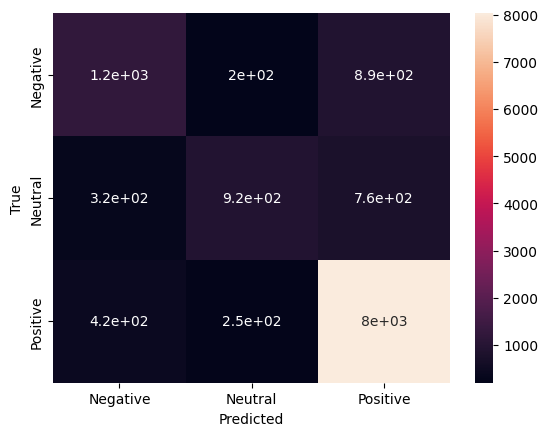

In [34]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        preds = model(x_batch).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


#Tuning!

In [35]:
le = LabelEncoder()
le.fit(train_df['Sentiment'].tolist() + test_df['Sentiment'].tolist())
train_df['label'] = le.transform(train_df['Sentiment'])
test_df['label'] = le.transform(test_df['Sentiment'])

In [38]:
def build_vocab_tune(texts, min_freq=2):
    counter = Counter()
    for text in texts:
        if isinstance(text, str):
            counter.update(text.lower().split())

    vocab = {"<pad>": 0, "<unk>": 1}
    idx = 2
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = idx
            idx += 1
    return vocab

vocab_tune = build_vocab_tune(train_df['cleaned'])
vocab_size = max(vocab.values()) + 1
max_len = 100

In [37]:
# --- Dataset Class ---
class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def encode_text(self, text):
        if not isinstance(text, str):
            text = ""
        tokens = text.lower().split()
        token_ids = [self.vocab.get(tok, self.vocab["<unk>"]) for tok in tokens]
        token_ids = token_ids[:self.max_len] + [self.vocab["<pad>"]] * (self.max_len - len(token_ids))
        return torch.tensor(token_ids)

    def __getitem__(self, idx):
        x = self.encode_text(self.texts[idx])
        y = torch.tensor(self.labels[idx])
        return x, y

In [39]:
_dataset = TextDataset(train_df['cleaned'].tolist(), train_df['label'].tolist(), vocab_tune, max_len)
test_dataset = TextDataset(test_df['cleaned'].tolist(), test_df['label'].tolist(), vocab_tune, max_len)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [41]:
# --- Model ---
class NonCausalTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim, num_layers, num_classes, max_len):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, embed_dim)
        self.pos_embed = nn.Embedding(max_len, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, dim_feedforward=ff_dim)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(0.3)
        self.norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, num_classes)
        )

    def forward(self, x):
        pos = torch.arange(0, x.size(1), device=x.device).unsqueeze(0)
        x = self.token_embed(x) + self.pos_embed(pos)
        x = self.encoder(x)
        x = x.mean(dim=1)  # Global average pooling
        x = self.norm(self.dropout(x))
        return self.classifier(x)

In [42]:
# --- Training ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = NonCausalTransformer(vocab_size, 128, 4, 256, 2, len(le.classes_), max_len).to(device)

In [44]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
class_weights = compute_class_weight('balanced', classes=np.unique(train_df['label']), y=train_df['label'])
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

In [45]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

In [46]:
def train_model(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(x_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_model(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            preds = model(x_batch)
            loss = criterion(preds, y_batch)
            total_loss += loss.item()
            all_preds.extend(torch.argmax(preds, dim=1).cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    acc = (np.array(all_preds) == np.array(all_labels)).mean()
    return total_loss / len(loader), acc

for epoch in range(10):
    train_loss = train_model(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = eval_model(model, test_loader, criterion, device)
    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}, Val Acc = {val_acc:.4f}")

Streaming output truncated to the last 5000 lines.
Epoch 10: Train Loss = 0.7717, Val Loss = 1.0472, Val Acc = 0.5300


In [47]:
# --- Evaluation ---
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        preds = model(x_batch).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

              precision    recall  f1-score   support

    Negative       0.32      0.05      0.09      2328
     Neutral       0.24      0.74      0.36      2001
    Positive       0.81      0.61      0.70      8708

    accuracy                           0.53     13037
   macro avg       0.46      0.47      0.38     13037
weighted avg       0.64      0.53      0.54     13037



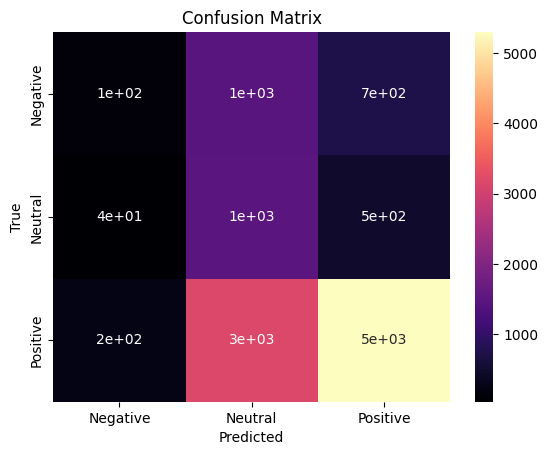

In [48]:
print(classification_report(all_labels, all_preds, target_names=le.classes_))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt=".0e", xticklabels=le.classes_, yticklabels=le.classes_, cmap="magma")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
# Evaluate model1
val_loss1, val_acc1 = eval_model(model1, test_loader, criterion, device)
print(f"Model 1 - Val Loss: {val_loss1:.4f}, Val Acc: {val_acc1:.4f}")

# Evaluate model2
val_loss2, val_acc2 = eval_model(model2, test_loader, criterion, device)
print(f"Model 2 - Val Loss: {val_loss2:.4f}, Val Acc: {val_acc2:.4f}")
